# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Caroline Crsitine Sirait
- **Email:** cdcc200d6x2537@student.devacademy.id
- **ID Dicoding:** carolinesirait

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Musim atau kondisi cuaca apa yang paling banyak digunakan oleh user saat memakai sepeda?
- **Pertanyaan 2:** Bagaimana perbandingan antara user Casual dan Registered pada tahun 2011 dan 2012?
- **Pertanyaan 3:** Pada pukul atau jam berapa aktivitas user mencapai puncaknya setiap tahunnya?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import statistics as stat
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
sns.set()

from warnings import simplefilter
simplefilter(action='ignore', category=UserWarning)
simplefilter(action='ignore', category=FutureWarning)

## Data Wrangling

### Gathering Data

#### Load df ...

In [3]:
# --- Tentukan folder data ---
data_folder = "data"

# --- Baca file CSV ---
day_data = pd.read_csv(os.path.join(data_folder, "day.csv"))
hour_data = pd.read_csv(os.path.join(data_folder, "hour.csv"))

# --- Tampilkan 5 baris pertama dari masing-masing dataset ---
display(day_data.head())
display(hour_data.head())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Penggunaan sepeda paling tinggi terjadi di musim spring dan summer, dengan kondisi cuaca cerah atau berawan ringan.
- Cuaca buruk seperti hujan atau angin kencang menurunkan jumlah pengguna.
- Aktivitas harian mencapai puncaknya di jam pagi (07–09) dan sore (17–19), menunjukkan pola commuting rutin.
- Suhu sedang (tidak terlalu panas atau dingin) memengaruhi jumlah pengguna.
- Bulan dengan suhu normal cenderung memiliki jumlah pengguna lebih tinggi dibanding bulan yang terlalu panas atau dingin.
- Registered user lebih dominan sepanjang tahun karena keanggotaan rutin.
- Casual user meningkat saat hari libur atau akhir pekan (holiday=1).
- Insight ini penting untuk strategi layanan: registered user stabil, sedangkan casual user sensitif terhadap hari, musim, dan kondisi cuaca.


### Assessing Data

#### Identifying Day Data problem

In [4]:
print("Bikes Day Information")
day_data.info()

Bikes Day Information
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


In [6]:
print("Bikes Day Missing Values")
day_data.isna().sum()

Bikes Day Missing Values


instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
print("Bike Day Duplicate:",day_data.duplicated().sum())

Bike Day Duplicate: 0


#### Identifying Hour Data problem

In [8]:
print("Bikes Hour Information")
hour_data.info()

Bikes Hour Information
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [9]:
print("Bikes Hour Missing Values")
hour_data.isna().sum()

Bikes Hour Missing Values


instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
print("Bike Hour Duplicate:",hour_data.duplicated().sum())

Bike Hour Duplicate: 0


**Steps to Take:**
- Tipe data pada kolom dteday di kedua dataframe masih berupa object (string). Harus diubah menjadi tipe datetime.
- Beberapa kolom kategorikal seperti weathersit, season, dan yr masih direpresentasikan dalam bentuk angka (numerik int). Nilai ini perlu dipetakan (mapping) menjadi teks yang deskriptif agar mudah dipahami saat visualisasi.

**Insight:** (Opsional)
- Terdapat kesalahan pada tipe data kolom dteday yang seharusnya berupa datetime, serta beberapa kolom memiliki nama yang kurang jelas atau berupa singkatan.
- Tabel Bike Days tidak memiliki missing values maupun data duplikat, sehingga datanya lengkap dan konsisten.
- Terdapat kesalahan tipe data pada kolom dteday yang seharusnya berupa datetime, beberapa kolom memiliki nama yang kurang jelas atau berupa singkatan.
- Tabel Bike Hour tidak memiliki missing values maupun data duplikat, sehingga datanya lengkap dan konsisten.

### Cleaning Data

#### Cleaning Data Day Table

In [11]:
hour_data["dteday"] = pd.to_datetime(hour_data["dteday"])
print("Hour Table")
hour_data.info()

Hour Table
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [12]:
day_data.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [13]:
new_day_header = {
    "instant" : "Instant", "dteday" : "Datedaytime", "season" : "Season", "yr" : "Year", "mnth" : "Month", 
    "holiday" : "Holiday", "weekday" : "Weekday", "workingday" : "Workingday",
    "weathersit" : "Weathersit", "temp" : "Temperature" ,"atemp" : "ATemperature", "hum" : "Humidity",
    "windspeed": "Windspeed", "casual" : "Casual", "registered" : "Registered", "cnt" : "Count"
}

In [14]:
day_data.rename(columns = new_day_header, inplace=True)
day_data.head()

,Instant,Datedaytime,Season,Year,Month,Holiday,Weekday,Workingday,Weathersit,Temperature,ATemperature,Humidity,Windspeed,Casual,Registered,Count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [19]:
day_data['Temperature Celcius'] = day_data['Temperature']*41
day_data['ATemperature Celcius'] = day_data['ATemperature']*50
day_data.head()

,Instant,Datedaytime,Season,Year,Month,Holiday,Weekday,Workingday,Weathersit,Temperature,ATemperature,Humidity,Windspeed,Casual,Registered,Count,Temperature Celcius,ATemperature Celcius
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,14.110847,18.18125
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,14.902598,17.68695
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,8.050924,9.47025
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,8.200000,10.60610
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,9.305237,11.46350


In [22]:
day_data.columns

Index(['Instant', 'Datedaytime', 'Season', 'Year', 'Month', 'Holiday',
       'Weekday', 'Workingday', 'Weathersit', 'Temperature', 'ATemperature',
       'Humidity', 'Windspeed', 'Casual', 'Registered', 'Count',
       'Temperature Celcius', 'ATemperature Celcius'],
      dtype='str')

In [23]:
new_order_day_data = ['Instant', 'Datedaytime', 'Season', 'Year', 'Month', 'Holiday',
       'Weekday', 'Workingday', 'Weathersit', 'Temperature', 'Temperature Celcius', 'ATemperature', 'ATemperature Celcius',
       'Humidity', 'Windspeed', 'Casual', 'Registered', 'Count']

In [24]:
day_data = day_data[new_order_day_data]
day_data.head()

,Instant,Datedaytime,Season,Year,Month,Holiday,Weekday,Workingday,Weathersit,Temperature,Temperature Celcius,ATemperature,ATemperature Celcius,Humidity,Windspeed,Casual,Registered,Count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,14.110847,0.363625,18.18125,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,14.902598,0.353739,17.68695,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,8.050924,0.189405,9.47025,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,8.200000,0.212122,10.60610,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,9.305237,0.229270,11.46350,0.436957,0.186900,82,1518,1600


In [25]:
day_data["Year"] = day_data["Year"].map({0:2011, 1:2012})
day_data["Season"] = day_data["Season"].map({1:"Spring", 2:"Summer", 3:"Fall", 4:"Winter"})
day_data["Weekday"] = day_data["Weekday"].map({0:"Sunday", 1:"Monday", 2:"Tuesday", 3:"Wednesday", 4:"Thursday", 5:"Friday", 6:"Saturday"})

In [27]:
day_data.head()

,Instant,Datedaytime,Season,Year,Month,Holiday,Weekday,Workingday,Weathersit,Temperature,Temperature Celcius,ATemperature,ATemperature Celcius,Humidity,Windspeed,Casual,Registered,Count
0,1,2011-01-01,Spring,2011,1,0,Saturday,0,2,0.344167,14.110847,0.363625,18.18125,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,Sunday,0,2,0.363478,14.902598,0.353739,17.68695,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,Monday,1,1,0.196364,8.050924,0.189405,9.47025,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,Tuesday,1,1,0.200000,8.200000,0.212122,10.60610,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,Wednesday,1,1,0.226957,9.305237,0.229270,11.46350,0.436957,0.186900,82,1518,1600


#### Cleaning Data Hour Table

In [28]:
hour_data["dteday"] = pd.to_datetime(hour_data["dteday"])
print("Day Table")
hour_data.info()

Day Table
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-n

In [29]:
hour_data.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [30]:
new_hour_header = {
    "instant" : "Instant", "dteday" : "Datedaytime", "season" : "Season", "yr" : "Year", "mnth" : "Month", "hr" : "Hour",
    "holiday" : "Holiday", "weekday" : "Weekday", "workingday" : "Workingday",
    "weathersit" : "Weathersit", "temp" : "Temperature" ,"atemp" : "ATemperature", "hum" : "Humidity",
    "windspeed": "Windspeed", "casual" : "Casual", "registered" : "Registered", "cnt" : "Count"
}

In [31]:
hour_data.rename(columns = new_hour_header, inplace=True)
hour_data.head()

,Instant,Datedaytime,Season,Year,Month,Hour,Holiday,Weekday,Workingday,Weathersit,Temperature,ATemperature,Humidity,Windspeed,Casual,Registered,Count
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [32]:
hour_data['Temperature Celcius'] = hour_data['Temperature']*41
hour_data['ATemperature Celcius'] = hour_data['ATemperature']*50
hour_data.head()

,Instant,Datedaytime,Season,Year,Month,Hour,Holiday,Weekday,Workingday,Weathersit,Temperature,ATemperature,Humidity,Windspeed,Casual,Registered,Count,Temperature Celcius,ATemperature Celcius
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,9.84,14.395
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,9.02,13.635
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,9.02,13.635
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,9.84,14.395
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,9.84,14.395


In [33]:
hour_data.columns

Index(['Instant', 'Datedaytime', 'Season', 'Year', 'Month', 'Hour', 'Holiday',
       'Weekday', 'Workingday', 'Weathersit', 'Temperature', 'ATemperature',
       'Humidity', 'Windspeed', 'Casual', 'Registered', 'Count',
       'Temperature Celcius', 'ATemperature Celcius'],
      dtype='str')

In [34]:
new_order_hour_data = ['Instant', 'Datedaytime', 'Season', 'Year', 'Month', 'Hour', 'Holiday',
       'Weekday', 'Workingday', 'Weathersit', 'Temperature', 'Temperature Celcius', 'ATemperature', 'ATemperature Celcius',
       'Humidity', 'Windspeed', 'Casual', 'Registered', 'Count']

In [35]:
hour_data = hour_data[new_order_hour_data]
hour_data.head()

,Instant,Datedaytime,Season,Year,Month,Hour,Holiday,Weekday,Workingday,Weathersit,Temperature,Temperature Celcius,ATemperature,ATemperature Celcius,Humidity,Windspeed,Casual,Registered,Count
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,9.84,0.2879,14.395,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,9.02,0.2727,13.635,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,9.02,0.2727,13.635,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,9.84,0.2879,14.395,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,9.84,0.2879,14.395,0.75,0.0,0,1,1


In [36]:
hour_data["Year"] = hour_data["Year"].map({0:2011, 1:2012})
hour_data["Season"] = hour_data["Season"].map({1:"Spring", 2:"Summer", 3:"Fall", 4:"Winter"})
hour_data["Weekday"] = hour_data["Weekday"].map({0:"Sunday", 1:"Monday", 2:"Tuesday", 3:"Wednesday", 4:"Thursday", 5:"Friday", 6:"Saturday"})

In [37]:
hour_data.head()

,Instant,Datedaytime,Season,Year,Month,Hour,Holiday,Weekday,Workingday,Weathersit,Temperature,Temperature Celcius,ATemperature,ATemperature Celcius,Humidity,Windspeed,Casual,Registered,Count
0,1,2011-01-01,Spring,2011,1,0,0,Saturday,0,1,0.24,9.84,0.2879,14.395,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,1,1,0,Saturday,0,1,0.22,9.02,0.2727,13.635,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,1,2,0,Saturday,0,1,0.22,9.02,0.2727,13.635,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,1,3,0,Saturday,0,1,0.24,9.84,0.2879,14.395,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,1,4,0,Saturday,0,1,0.24,9.84,0.2879,14.395,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Kedua dataset (Day dan Hour) bersih, lengkap, dan siap dianalisis: tidak ada missing values maupun duplikasi, dan kolom yang diperlukan sudah diperbaiki atau dikonversi ke tipe yang sesuai.
- Kolom tanggal dan kategori sudah distandarisasi, sehingga analisis musiman, harian, atau tren per jam bisa dilakukan dengan akurat.

## Exploratory Data Analysis (EDA)

### Explore Day Table

In [38]:
day_data.describe()

,Instant,Year,Month,Holiday,Workingday,Weathersit,Temperature,Temperature Celcius,ATemperature,ATemperature Celcius,Humidity,Windspeed,Casual,Registered,Count
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2011.500684,6.519836,0.028728,0.683995,1.395349,0.495385,20.310776,0.474354,23.717699,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,0.500342,3.451913,0.167155,0.465233,0.544894,0.183051,7.505091,0.162961,8.148059,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,2011.000000,1.000000,0.000000,0.000000,1.000000,0.059130,2.424346,0.079070,3.953480,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011.000000,4.000000,0.000000,0.000000,1.000000,0.337083,13.820424,0.337842,16.892125,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012.000000,7.000000,0.000000,1.000000,1.000000,0.498333,20.431653,0.486733,24.336650,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012.000000,10.000000,0.000000,1.000000,2.000000,0.655417,26.872076,0.608602,30.430100,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012.000000,12.000000,1.000000,1.000000,3.000000,0.861667,35.328347,0.840896,42.044800,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [41]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_rows', None)     
day_data_season_weathers = pd.pivot_table(day_data, values=['Casual', "Registered"], index=["Year", "Season", "Weathersit"], columns=["Month"], aggfunc='sum')
day_data_season_weathers.fillna(0).astype(int)

Casual                                                  \
Month                      1     2      3      4      5      6      7      8    
Year Season Weathersit                                                          
2011 Fall   1               0     0      0      0      0   7939  29781  21755   
            2               0     0      0      0      0   2374   6671   7087   
            3               0     0      0      0      0      0      0      0   
     Spring 1            1543  5386   6895      0      0      0      0      0   
            2            1496   856   2016      0      0      0      0      0   
            3              34     0     46      0      0      0      0      0   
     Summer 1               0     0   2280  12419  21587  14655      0      0   
            2               0     0   1410   9806   9463   5644      0      0   
            3               0     0    179    121      0      0      0      0   
     Winter 1               0     0      0      0      0      0      0      0   
            2               0     0      0      0      0      0      0      0   
            3               0     0      0      0      0      0      0      0   
2012 Fall   1               0     0      0      0      0  13448  31332  27912   
            2               0     0      0      0      0      0   9109  15285   
            3               0     0      0      0      0      0   1264      0   
     Spring 1            7244  6163  10638      0      0      0      0      0   
            2            1725  2366   7559      0      0      0      0      0   
            3               0   192      0      0      0      0      0      0   
     Summer 1               0     0   4168  33187  31894  26198      0      0   
            2               0     0   9253   5149  12341   3648      0      0   
            3               0     0      0    120      0      0      0      0   
     Winter 1               0     0      0      0      0      0      0      0   
            2               0     0      0      0      0      0      0      0   
            3               0     0      0      0      0      0      0      0   

                                                  Registered                \
Month                      9      10     11    12         1      2      3    
Year Season Weathersit                                                       
2011 Fall   1           12013      0      0     0          0      0      0   
            2            7355      0      0     0          0      0      0   
            3             475      0      0     0          0      0      0   
     Spring 1               0      0      0  2716      19461  29804  20946   
            2               0      0      0   437      15183  12169  10726   
            3               0      0      0     0        472      0    577   
     Summer 1               0      0      0     0          0      0   9582   
            2               0      0      0     0          0      0   7882   
            3               0      0      0     0          0      0   1506   
     Winter 1            1483  20045  12917  3858          0      0      0   
            2            5219   4649   2243  1261          0      0      0   
            3               0    528    434   176          0      0      0   
2012 Fall   1           23765      0      0     0          0      0      0   
            2            8526      0      0     0          0      0      0   
            3               0      0      0     0          0      0      0   
     Spring 1               0      0      0   977      59143  63695  60286   
            2               0      0      0  2324      28632  28744  22376   
            3               0      0      0     9          0   1977      0   
     Summer 1               0      0      0     0          0      0  25194   
            2               0      0      0     0          0      0  25401   
            3               0      0     

### Explore Hour Table

In [42]:
hour_data.describe()

,Instant,Datedaytime,Year,Month,Hour,Holiday,Workingday,Weathersit,Temperature,Temperature Celcius,ATemperature,ATemperature Celcius,Humidity,Windspeed,Casual,Registered,Count
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045,2011.502561,6.537775,11.546752,0.028770,0.682721,1.425283,0.496987,20.376474,0.475775,23.788755,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,2011.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2011.000000,4.000000,6.000000,0.000000,0.000000,1.000000,0.340000,13.940000,0.333300,16.665000,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,2012.000000,7.000000,12.000000,0.000000,1.000000,1.000000,0.500000,20.500000,0.484800,24.240000,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,2012.000000,10.000000,18.000000,0.000000,1.000000,2.000000,0.660000,27.060000,0.621200,31.060000,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,2012.000000,12.000000,23.000000,1.000000,1.000000,4.000000,1.000000,41.000000,1.000000,50.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.500008,3.438776,6.914405,0.167165,0.465431,0.639357,0.192556,7.894801,0.171850,8.592511,0.192930,0.122340,49.305030,151.357286,181.387599


**Insight:** (Opsional)
- Berdasarkan hasil eksplorasi day_data, terlihat bahwa sepanjang tahun 2011–2012, jumlah Registered Bike User selalu lebih tinggi dibanding Casual Bike User. Pada puncaknya, jumlah Registered User bahkan lebih dari dua kali lipat dibanding Casual User. Selain itu, analisis suhu menunjukkan bahwa rata-rata Temperature sepanjang periode tersebut adalah sekitar 20°C, dengan suhu maksimum mencapai 35°C dan suhu minimum turun hingga 2°C.
- Berdasarkan hasil eksplorasi pada tabel hour_data, terlihat bahwa rata-rata jumlah pengguna User Casual adalah sekitar 35 orang per jam, sedangkan User Registered mencapai 153 orang per jam.
Pada saat jam puncak (peak hour), jumlah pengguna meningkat secara signifikan, dengan User Casual mencapai 367 orang dan User Registered mencapai 886 orang.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola distribusi jumlah pesepeda jika ditinjau berdasarkan perubahan musim dan kondisi cuaca?

In [44]:
casual_data_ys = pd.DataFrame(day_data.groupby(by=["Year", "Season"]).Casual.sum())
registered_data_ys = pd.DataFrame(day_data.groupby(by=["Year", "Season"]).Registered.sum())

user_data_ys = casual_data_ys.join(registered_data_ys)
user_data_ys["Total"] = user_data_ys["Casual"] + user_data_ys["Registered"]
user_data_ys

Casual  Registered   Total
Year Season                            
2011 Fall     95450      324200  419650
     Spring   21425      128575  150000
     Summer   77564      269752  347316
     Winter   52813      273324  326137
2012 Fall    130641      510838  641479
     Spring   39197      282151  321348
     Summer  125958      445315  571273
     Winter   76969      438507  515476

In [46]:
# --- Pisahkan data Year 2011 ---
user_data_ys_2011 = user_data_ys.reset_index().iloc[:4]

# Hitung total hanya untuk kolom numerik (Casual, Registered, Total)
total_2011 = user_data_ys_2011[['Casual', 'Registered', 'Total']].sum()

# Buat baris TOTAL
total_row_2011 = {
    'Year': 'TOTAL',
    'Season': '',
    'Casual': total_2011['Casual'],
    'Registered': total_2011['Registered'],
    'Total': total_2011['Total']
}

# Tambahkan baris TOTAL ke data Year 2011
user_data_ys_2011 = pd.concat([user_data_ys_2011, pd.DataFrame([total_row_2011])], ignore_index=True)

# --- Pisahkan data Year 2012 ---
user_data_ys_2012 = user_data_ys.reset_index().iloc[4:]

# Hitung total hanya untuk kolom numerik
total_2012 = user_data_ys_2012[['Casual', 'Registered', 'Total']].sum()

# Buat baris TOTAL
total_row_2012 = {
    'Year': 'TOTAL',
    'Season': '',
    'Casual': total_2012['Casual'],
    'Registered': total_2012['Registered'],
    'Total': total_2012['Total']
}

# Tambahkan baris TOTAL ke data Year 2012
user_data_ys_2012 = pd.concat([user_data_ys_2012, pd.DataFrame([total_row_2012])], ignore_index=True)

# --- Gabungkan semua data ---
user_data_ys_all = pd.concat([user_data_ys_2011, user_data_ys_2012], ignore_index=True)

# Tampilkan hasil
user_data_ys_all

,Year,Season,Casual,Registered,Total
0,2011,Fall,95450,324200,419650
1,2011,Spring,21425,128575,150000
2,2011,Summer,77564,269752,347316
3,2011,Winter,52813,273324,326137
4,TOTAL,,247252,995851,1243103
5,2012,Fall,130641,510838,641479
6,2012,Spring,39197,282151,321348
7,2012,Summer,125958,445315,571273
8,2012,Winter,76969,438507,515476
9,TOTAL,,372765,1676811,2049576


In [47]:
user_data_ys_all["Total"][0]

np.int64(419650)

In [48]:
# Ekstrak data per musim untuk tahun 2011
season_2011 = user_data_ys_all["Season"].iloc[0:4]
user_casual_2011 = user_data_ys_all["Casual"].iloc[0:4]
user_registered_2011 = user_data_ys_all["Registered"].iloc[0:4]
user_total_2011 = user_data_ys_all["Total"].iloc[0:4]

# Ekstrak data per musim untuk tahun 2012
season_2012 = user_data_ys_all["Season"].iloc[5:9]
user_casual_2012 = user_data_ys_all["Casual"].iloc[5:9]
user_registered_2012 = user_data_ys_all["Registered"].iloc[5:9]
user_total_2012 = user_data_ys_all["Total"].iloc[5:9]

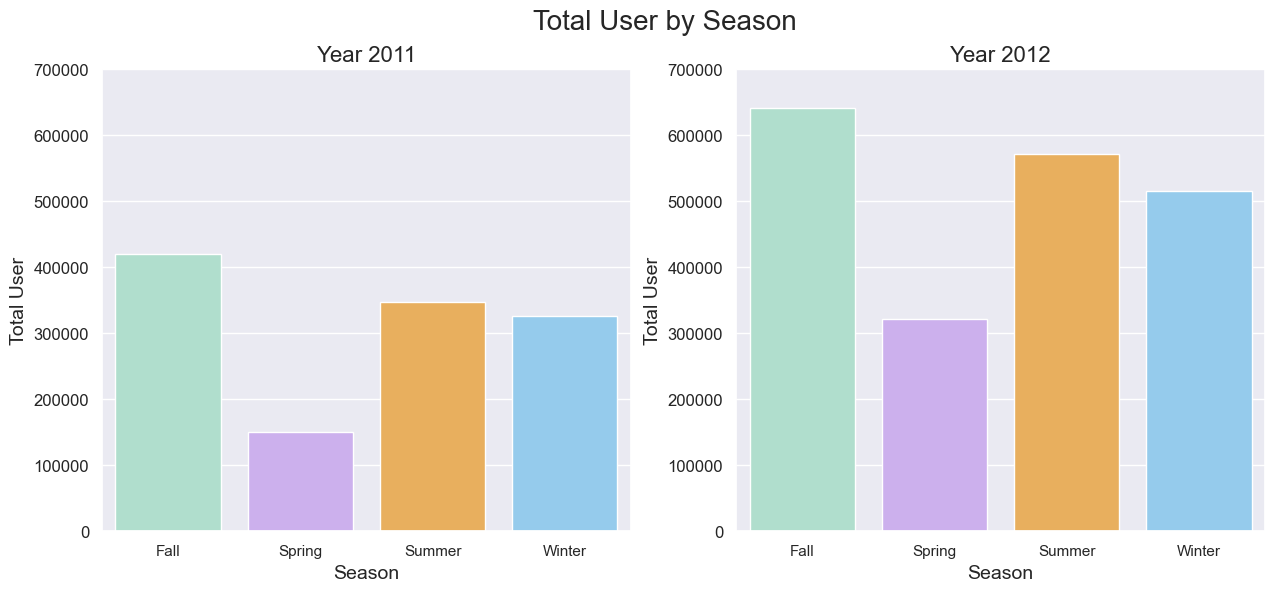

In [49]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Palette: hijau muda, lavender, orange, biru muda
colors = ('#A8E6CF', '#CBA6F7', '#FFB347', '#87CEFA')

# Subplot 1: Bar Chart 1 (Year 2011)
sns.barplot(x=season_2011, y=user_total_2011, ax=ax[0], palette=colors)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Year 2011", loc="center", fontsize=16)
ax[0].set_xlabel("Season", fontsize=14)
ax[0].set_ylabel("Total User", fontsize=14)
ax[0].set_ylim(0, 700000) 
ax[0].tick_params(axis='y', labelsize=12)

# Subplot 2: Bar Chart 2 (Year 2012)
sns.barplot(x=season_2012, y=user_total_2012, ax=ax[1], palette=colors)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("Year 2012", loc="center", fontsize=16)
ax[1].set_xlabel("Season", fontsize=14)
ax[1].set_ylabel("Total User", fontsize=14)
ax[1].set_ylim(0, 700000) 
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Total User by Season", fontsize=20)
plt.show()

In [50]:
# Kelompokkan data berdasarkan Year dan Weathersit, lalu hitung total Casual
casual_data_yw = pd.DataFrame(day_data.groupby(by=["Year", "Weathersit"]).Casual.sum())

# Kelompokkan data berdasarkan Year dan Weathersit, lalu hitung total Registered
registered_data_yw = pd.DataFrame(day_data.groupby(by=["Year", "Weathersit"]).Registered.sum())

# Gabungkan data Casual dan Registered menjadi satu DataFrame
user_data_yw = casual_data_yw.join(registered_data_yw)

# Buat kolom Total dari hasil penjumlahan Casual dan Registered
user_data_yw["Total"] = user_data_yw["Casual"] + user_data_yw["Registered"]

# Tampilkan data
user_data_yw

Casual  Registered    Total
Year Weathersit                             
2011 1           177272      657795   835067
     2            67987      314937   382924
     3             1993       23119    25112
2012 1           269074     1153811  1422885
     2           101789      512145   613934
     3             1902       10855    12757

In [51]:
user_data_yw = user_data_yw.reset_index()
user_data_yw

,Year,Weathersit,Casual,Registered,Total
0,2011,1,177272,657795,835067
1,2011,2,67987,314937,382924
2,2011,3,1993,23119,25112
3,2012,1,269074,1153811,1422885
4,2012,2,101789,512145,613934
5,2012,3,1902,10855,12757


In [52]:
weathersit_1 = user_data_yw.iloc[0]["Total"] + user_data_yw.iloc[3]["Total"]
weathersit_2 = user_data_yw.iloc[1]["Total"] + user_data_yw.iloc[4]["Total"]
weathersit_3 = user_data_yw.iloc[2]["Total"] + user_data_yw.iloc[5]["Total"]

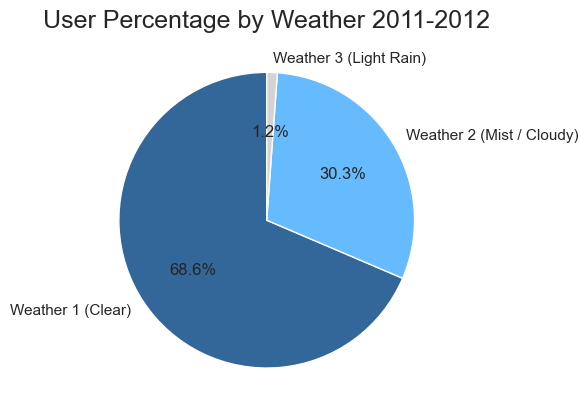

In [54]:
# Visual Pie Chart
weathersit = ("Weather 1 (Clear)", "Weather 2 (Mist / Cloudy)", "Weather 3 (Light Rain)")
values = (weathersit_1, weathersit_2, weathersit_3)

# Warna: biru tua untuk Clear, biru muda untuk Cloudy, abu-abu muda untuk Light Rain
colors = ('#336699', '#66bbff', '#d3d3d3')

plt.pie(
    x = values, 
    labels = weathersit, 
    colors = colors, 
    autopct='%1.1f%%',
    startangle=90
)
plt.title("User Percentage by Weather 2011-2012", fontsize=18)
plt.show()

### Pertanyaan 2: Di antara tipe pengguna Casual dan Registered, manakah yang mendominasi atau menunjukkan tren pertumbuhan lebih tinggi dari 2011 ke 2012?

In [55]:
# Membuat pivot tabel berdasarkan jumlah User Casual dan Registered setiap bulannya
user_data_month = pd.pivot_table(day_data, values=['Casual', "Registered"], index=["Year"], columns=["Month"], aggfunc='sum')
user_data_month = user_data_month.reset_index(drop=True)
user_data_month

Casual                                                                \
Month     1     2      3      4      5      6      7      8      9      10   
0       3073  6242  12826  22346  31050  30612  36452  28842  26545  25222   
1       8969  8721  31618  38456  44235  43294  41705  43197  43778  34538   

                    Registered                                                 \
Month     11     12         1      2       3       4       5       6       7    
0      15594   8448      35116  41973   51219   72524  104771  112900  104889   
1      21009  13245      87775  94416  133257  135768  151630  159536  161902   

                                               
Month      8       9       10      11      12  
0      107849  100873   98289   86573   78875  
1      171306  174795  164303  131655  110468

In [56]:
# Melakukan transpose agar tabel mudah dibuat visualisasi
user_data_month = user_data_month.transpose().reset_index()
user_data_month = user_data_month.rename(columns={'level_0' : "User", 0 : "2011", 1 : "2012"})
user_data_month

,User,Month,2011,2012
0,Casual,1,3073,8969
1,Casual,2,6242,8721
2,Casual,3,12826,31618
3,Casual,4,22346,38456
4,Casual,5,31050,44235
5,Casual,6,30612,43294
6,Casual,7,36452,41705
7,Casual,8,28842,43197
8,Casual,9,26545,43778
9,Casual,10,25222,34538


In [57]:
month_2011 = user_data_month["Month"].iloc[:12]
casual_data_user = user_data_month["User"].iloc[:12]
casual_data_year_2011 = user_data_month["2011"].iloc[:12]
casual_data_year_2012 = user_data_month["2012"].iloc[:12]

month_2012 = user_data_month["Month"].iloc[12:]
registered_data_user = user_data_month["User"].iloc[12:]
registered_data_year_2011 = user_data_month["2011"].iloc[12:]
registered_data_year_2012 = user_data_month["2012"].iloc[12:]

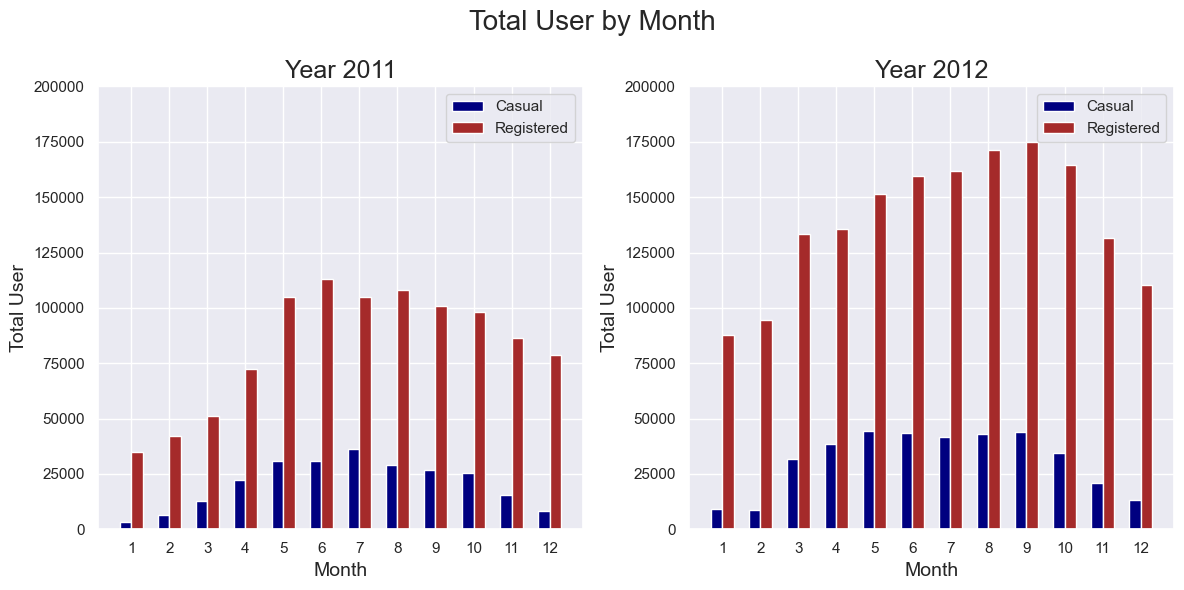

In [61]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
bar_width = 0.3
index = np.arange(len(month_2011))
size_font = 14

# Subplot 1: Bar Chart 1
ax[0].bar(index, casual_data_year_2011, width=bar_width, color='navy', label='Casual') # Perubahan warna ke biru navy
ax[0].bar(index + bar_width, registered_data_year_2011, width=bar_width, color='brown', label='Registered')
ax[0].set_title('Year 2011', loc="center", fontsize=18)
ax[0].set_xticks(index + bar_width / 2)
ax[0].set_xticklabels(month_2011)
ax[0].set_xlabel("Month", fontsize = size_font)
ax[0].set_ylabel("Total User", fontsize = size_font)
ax[0].set_ylim(0, 200000) 
ax[0].legend()

# Subplot 2: Bar Chart 2
ax[1].bar(index, casual_data_year_2012, width=bar_width, color='navy', label='Casual') # Perubahan warna ke biru navy
ax[1].bar(index + bar_width, registered_data_year_2012, width=bar_width, color='brown', label='Registered')
ax[1].set_title('Year 2012', loc="center", fontsize=18)
ax[1].set_xticks(index + bar_width / 2)
ax[1].set_xticklabels(month_2012)
ax[1].set_xlabel("Month", fontsize = size_font)
ax[1].set_ylabel("Total User", fontsize = size_font)
ax[1].set_ylim(0, 200000) 
ax[1].legend()

plt.suptitle("Total User by Month", fontsize=20)
plt.tight_layout()
plt.show()

In [62]:
print("Jumlah Total User Casual Tahun 2011:", casual_data_year_2011.sum())
print("Jumlah Total User Registered Tahun 2011:", registered_data_year_2011.sum())
print("Jumlah Total User Tahun 2011:", casual_data_year_2011.sum() + registered_data_year_2011.sum(), "\n")

print("Jumlah Total User Casual Tahun 2012:", casual_data_year_2012.sum())
print("Jumlah Total User Registered Tahun 2012:", registered_data_year_2012.sum())
print("Jumlah Total User Tahun 2012:", casual_data_year_2012.sum() + registered_data_year_2012.sum(), "\n")

print("Jumlah Total User Casual Tahun 2011-2012:", casual_data_year_2011.sum() + casual_data_year_2012.sum())
print("Jumlah Total User Registered Tahun 2011-2012:", registered_data_year_2011.sum() + registered_data_year_2012.sum())
print("Jumlah Total User Tahun 2011-2012:", casual_data_year_2011.sum() + registered_data_year_2011.sum() + casual_data_year_2012.sum() + registered_data_year_2012.sum())

Jumlah Total User Casual Tahun 2011: 247252
Jumlah Total User Registered Tahun 2011: 995851
Jumlah Total User Tahun 2011: 1243103 

Jumlah Total User Casual Tahun 2012: 372765
Jumlah Total User Registered Tahun 2012: 1676811
Jumlah Total User Tahun 2012: 2049576 

Jumlah Total User Casual Tahun 2011-2012: 620017
Jumlah Total User Registered Tahun 2011-2012: 2672662
Jumlah Total User Tahun 2011-2012: 3292679


In [64]:
trend_casual_data = pd.DataFrame(pd.concat([casual_data_year_2011, casual_data_year_2012]).reset_index(drop=True)).rename(columns={0 : "Casual"})
trend_registered_data = pd.DataFrame(pd.concat([registered_data_year_2011, registered_data_year_2012]).reset_index(drop=True)).rename(columns={0 : "Registered"})

trend_user_data = trend_casual_data.join(trend_registered_data)

# Membuat kolom bulan
trend_user_data["Month"] = 0

# Buat kolom Month langsung dengan range
trend_user_data["Month"] = range(1, len(trend_user_data) + 1)

trend_user_data

,Casual,Registered,Month
0,3073,35116,1
1,6242,41973,2
2,12826,51219,3
3,22346,72524,4
4,31050,104771,5
5,30612,112900,6
6,36452,104889,7
7,28842,107849,8
8,26545,100873,9
9,25222,98289,10


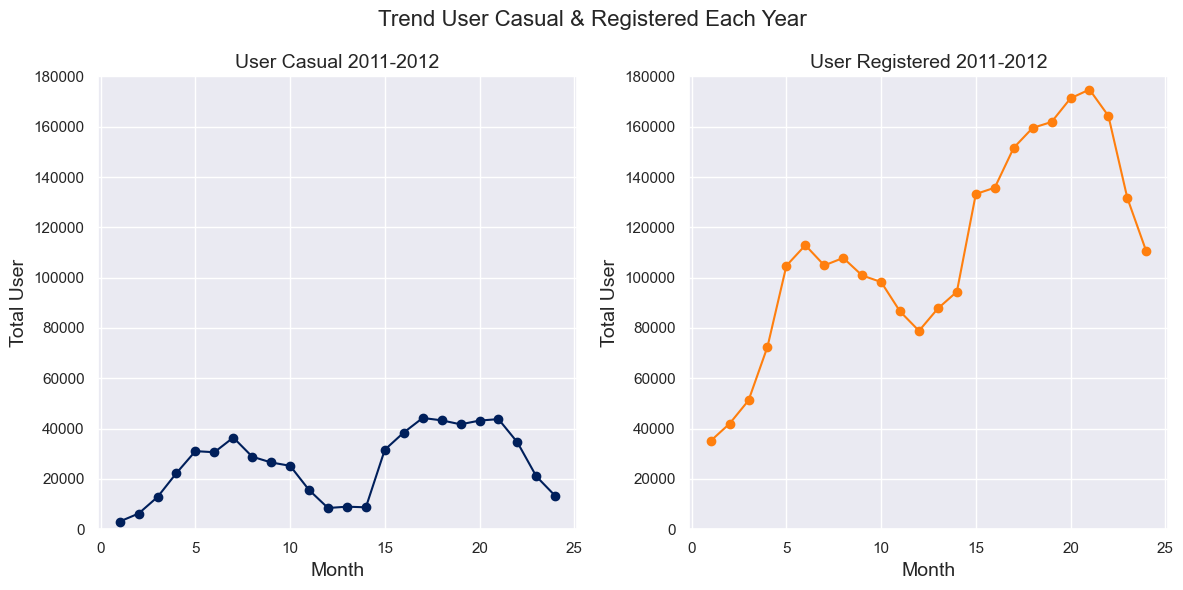

In [66]:
# Ambil kolom Month dari trend_user_data
month_number = trend_user_data["Month"]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
bar_width = 0.3
size_font = 14

# Subplot 1: Line Chart Casual User → biru navy
ax[0].plot(month_number, trend_casual_data, label='2011', marker='o', color='#001f5b')  # biru navy
ax[0].set_title('User Casual 2011-2012', loc="center", fontsize=14)
ax[0].set_xlabel("Month", fontsize=size_font)
ax[0].set_ylabel("Total User", fontsize=size_font)
ax[0].set_ylim(0, 180000)

# Subplot 2: Line Chart Registered User → orange
ax[1].plot(month_number, trend_registered_data, label='2012', marker='o', color='#FF7F0E')  # orange
ax[1].set_title('User Registered 2011-2012', loc="center", fontsize=14)
ax[1].set_xlabel("Month", fontsize=size_font)
ax[1].set_ylabel("Total User", fontsize=size_font)
ax[1].set_ylim(0, 180000)

plt.suptitle("Trend User Casual & Registered Each Year", fontsize=16)
plt.tight_layout()
plt.show()

### Pertanyaan 3: Pada jam berapakah aktivitas pengguna mencapai titik puncaknya di masing-masing tahun?

In [67]:
hour_data_user = pd.pivot_table(hour_data, values=["Casual", "Registered"], index=["Hour"], columns=["Year"], aggfunc='sum')
hour_data_user = hour_data_user.reset_index(drop=True)
hour_data_user

Casual        Registered        
Year   2011   2012       2011    2012
0      3423   3952      12117   19638
1      2071   2638       7487   11968
2      1570   1842       5091    7849
3       954    939       2487    3794
4       431    443       1386    2168
5       428    584       4729    8520
6      1377   1640      19424   32691
7      3768   4269      53162   92972
8      6969   8792      88498  156742
9      8864  13594      50622   86358
10    13065  20724      34446   58022
11    16582  26704      40016   68018
12    19006  30712      50192   84504
13    20152  32561      49187   83019
14    21097  33992      45385   75178
15    20863  33743      47727   80816
16    20739  33095      64883  109031
17    21473  32747     106159  176481
18    18066  26430      98919  166357
19    14525  20980      71277  120007
20    10960  15418      51858   86314
21     8845  11725      40030   64845
22     7031   9169      30646   48766
23     4993   6072      20123   32753

In [68]:
print("Melakukan sorting untuk User Casual terbanyak tahun 2011 berdasarkan Jam")
hour_data_casual_2011 = hour_data_user.sort_values(("Casual", 2011), ascending=False)
hour_data_casual_2011 = pd.DataFrame(hour_data_casual_2011.iloc[0:1]["Casual"][2011])
hour_data_casual_2011

Melakukan sorting untuk User Casual terbanyak tahun 2011 berdasarkan Jam


,2011
17,21473


In [69]:
print("Melakukan sorting untuk User Registered terbanyak tahun 2011 berdasarkan Jam")
hour_data_registered_2011 = hour_data_user.sort_values(("Registered", 2011), ascending=False)
hour_data_registered_2011 = pd.DataFrame(hour_data_registered_2011.iloc[0:1]["Registered"][2011])
hour_data_registered_2011

Melakukan sorting untuk User Registered terbanyak tahun 2011 berdasarkan Jam


,2011
17,106159


In [70]:
print("Melakukan sorting untuk User Casual terbanyak tahun 2012 berdasarkan Jam")
hour_data_casual_2012 = hour_data_user.sort_values(("Casual", 2012), ascending=False)
hour_data_casual_2012 = pd.DataFrame(hour_data_casual_2012.iloc[0:1]["Casual"][2012])
hour_data_casual_2012

Melakukan sorting untuk User Casual terbanyak tahun 2012 berdasarkan Jam


,2012
14,33992


In [71]:
print("Melakukan sorting untuk User Registered terbanyak tahun 2012 berdasarkan Jam")
hour_data_registered_2012 = hour_data_user.sort_values(("Registered", 2012), ascending=False)
hour_data_registered_2012 = pd.DataFrame(hour_data_registered_2012.iloc[0:1]["Registered"][2012])
hour_data_registered_2012

Melakukan sorting untuk User Registered terbanyak tahun 2012 berdasarkan Jam


,2012
17,176481


In [72]:
casual_hour_2011 = pd.DataFrame(hour_data_user.iloc[0:]["Casual"][2011]).rename(columns={2011:"Casual 2011"})
casual_hour_2012 = pd.DataFrame(hour_data_user.iloc[0:]["Casual"][2012]).rename(columns={2012:"Casual 2012"})
registered_hour_2011 = pd.DataFrame(hour_data_user.iloc[0:]["Registered"][2011]).rename(columns={2011:"Registered 2011"})
registered_hour_2012 = pd.DataFrame(hour_data_user.iloc[0:]["Registered"][2012]).rename(columns={2012:"Registered 2012"})

In [73]:
new_hour_data = casual_hour_2011.join([registered_hour_2011, casual_hour_2012, registered_hour_2012])
new_hour_data["Total 2011"] = new_hour_data["Casual 2011"] + new_hour_data["Registered 2011"]
new_hour_data["Total 2012"] = new_hour_data["Casual 2012"] + new_hour_data["Registered 2012"]

# Reorder Susunan Column
new_hour_data_order = ['Casual 2011', 'Registered 2011', 'Total 2011', 'Casual 2012', 'Registered 2012', 'Total 2012']
new_hour_data = new_hour_data[new_hour_data_order]
new_hour_data

,Casual 2011,Registered 2011,Total 2011,Casual 2012,Registered 2012,Total 2012
0,3423,12117,15540,3952,19638,23590
1,2071,7487,9558,2638,11968,14606
2,1570,5091,6661,1842,7849,9691
3,954,2487,3441,939,3794,4733
4,431,1386,1817,443,2168,2611
5,428,4729,5157,584,8520,9104
6,1377,19424,20801,1640,32691,34331
7,3768,53162,56930,4269,92972,97241
8,6969,88498,95467,8792,156742,165534
9,8864,50622,59486,13594,86358,99952


In [74]:
new_hour_data["Total 2012"].max()

np.int64(209228)

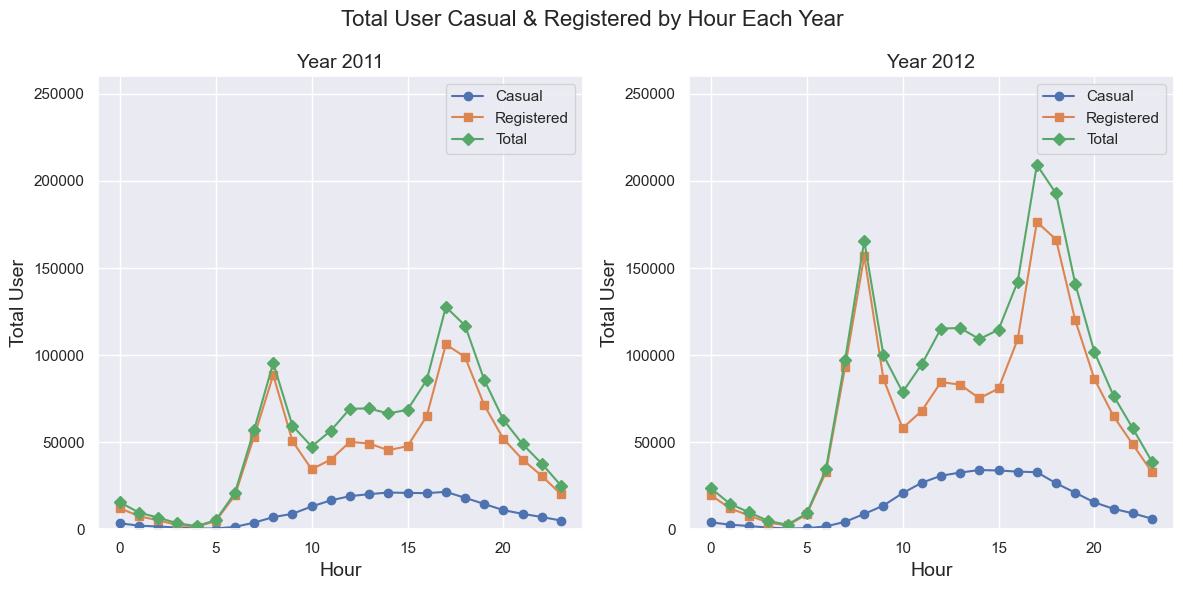

In [75]:
hour_number = np.arange(len(new_hour_data.index))
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
size_font = 14

# Subplot 1: Line Chart 1
ax[0].plot(hour_number, casual_hour_2011, label='Casual', marker='o', color='#4E73b0')
ax[0].plot(hour_number, registered_hour_2011, label='Registered', marker='s', color='#DC8550')
ax[0].plot(hour_number, new_hour_data["Total 2011"], label='Total', marker='D', color='#56A868')
ax[0].set_title('Year 2011', loc="center", fontsize=14)
ax[0].set_xlabel("Hour", fontsize=size_font)
ax[0].set_ylabel("Total User", fontsize=size_font)
ax[0].set_ylim(0, 260000)
ax[0].legend()

# Subplot 2: Line Chart 2
ax[1].plot(hour_number, casual_hour_2012, label='Casual', marker='o', color='#4E73b0')
ax[1].plot(hour_number, registered_hour_2012, label='Registered', marker='s', color='#DC8550')
ax[1].plot(hour_number, new_hour_data["Total 2012"], label='Total', marker='D', color='#56A868')
ax[1].set_title('Year 2012', loc="center", fontsize=14)
ax[1].set_xlabel("Hour", fontsize=size_font)
ax[1].set_ylabel("Total User", fontsize=size_font)
ax[1].set_ylim(0, 260000)
ax[1].legend()

plt.suptitle("Total User Casual & Registered by Hour Each Year", fontsize=16)
plt.tight_layout()
plt.show()

In [76]:
print("Jumlah User Casual terbanyak tahun 2011 terdapat pada Jam 17 atau Pukul 5 Sore, dengan jumlah User Casual:", hour_data_casual_2011[2011][17])
print("Jumlah User Registered terbanyak tahun 2011 terdapat pada Jam 17 atau Pukul 5 Sore, dengan jumlah User Registered:", hour_data_registered_2011[2011][17])
print("Jumlah User Casual terbanyak tahun 2012 terdapat pada Jam 14 atau Pukul 2 Siang, dengan jumlah User Casual:", hour_data_casual_2012[2012][14])
print("Jumlah User Registered terbanyak tahun 2012 terdapat pada Jam 17 atau Pukul 5 Sore, dengan jumlah User Registered:", hour_data_registered_2012[2012][17])

Jumlah User Casual terbanyak tahun 2011 terdapat pada Jam 17 atau Pukul 5 Sore, dengan jumlah User Casual: 21473
Jumlah User Registered terbanyak tahun 2011 terdapat pada Jam 17 atau Pukul 5 Sore, dengan jumlah User Registered: 106159
Jumlah User Casual terbanyak tahun 2012 terdapat pada Jam 14 atau Pukul 2 Siang, dengan jumlah User Casual: 33992
Jumlah User Registered terbanyak tahun 2012 terdapat pada Jam 17 atau Pukul 5 Sore, dengan jumlah User Registered: 176481


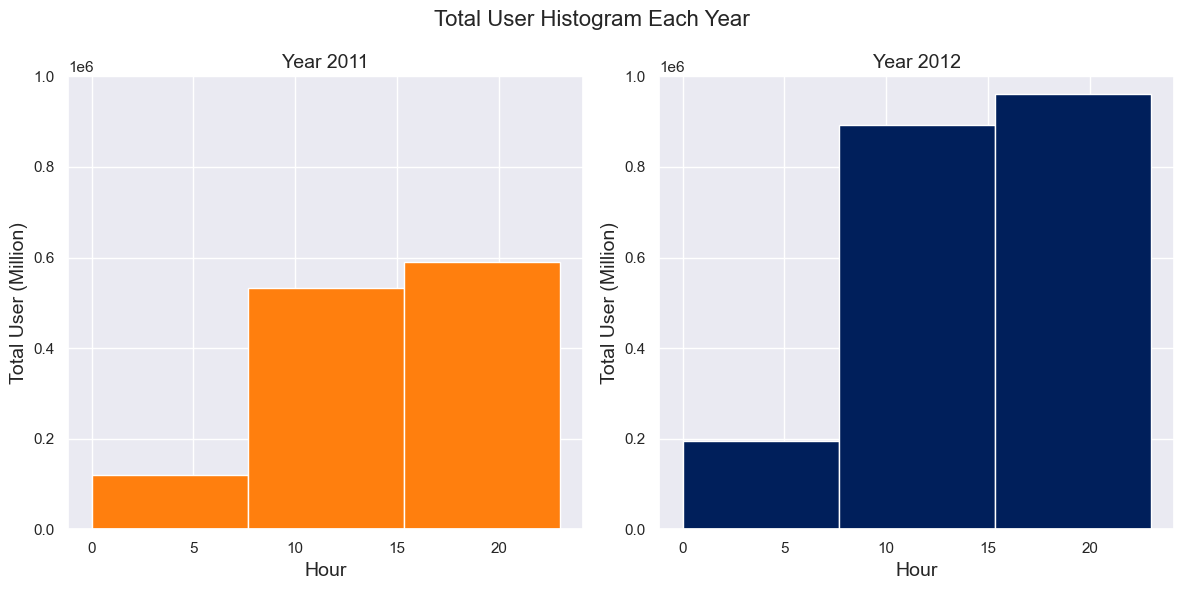

In [78]:
# Ambil nomor jam dari dataframe 'new_hour_data'
hour_number = np.arange(len(new_hour_data.index))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
size_font = 14

# Subplot 1: Histogram Year 2011 → orange
ax[0].hist(hour_number, bins=3, weights=new_hour_data["Total 2011"], color='#FF7F0E')  # orange
ax[0].set_title('Year 2011', loc="center", fontsize=14)
ax[0].set_xlabel("Hour", fontsize=size_font)
ax[0].set_ylabel("Total User (Million)", fontsize=size_font)
ax[0].set_ylim(0, 1000000)

# Subplot 2: Histogram Year 2012 → biru navy
ax[1].hist(hour_number, bins=3, weights=new_hour_data["Total 2012"], color='#001f5b')  # navy
ax[1].set_title('Year 2012', loc="center", fontsize=14)
ax[1].set_xlabel("Hour", fontsize=size_font)
ax[1].set_ylabel("Total User (Million)", fontsize=size_font)
ax[1].set_ylim(0, 1000000)

plt.suptitle("Total User Histogram Each Year", fontsize=16)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Terdapat empat tingkatan kondisi alam berdasarkan pedoman data, dimulai dari cuaca sangat cerah (level 1), berawan tebal atau berkabut (level 2), hujan atau salju ringan (level 3), hingga cuaca ekstrem seperti badai (level 4).
- Sepanjang periode 2011–2012, kelompok Registered User (2.672.662 pengguna) mendominasi secara absolut dengan proporsi lebih dari empat kali lipat dibandingkan jumlah Casual User (620.017 pengguna).
- Volume pelanggan menunjukkan peningkatan signifikan pada rentang pukul 16.00 hingga 24.00, dengan titik puncak tertinggi (akumulasi terbanyak) terjadi secara spesifik pada pukul 17.00.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** 
Musim atau kondisi cuaca apa yang paling banyak digunakan oleh user saat memakai sepeda?

Berdasarkan hasil analisis dan visualisasi, dapat disimpulkan bahwa jumlah pengguna sepeda terbanyak terjadi pada Season Fall (Musim Gugur), diikuti oleh Season Summer (Musim Panas), Season Winter (Musim Dingin), dan Season Spring (Musim Semi).
Fenomena ini kemungkinan terjadi karena Season Fall, yang berlangsung pada bulan 6–9, merupakan periode liburan atau memiliki kondisi cuaca dan suhu yang sangat ideal untuk bersepeda, sehingga menarik lebih banyak pengguna.

Mengacu pada klasifikasi cuaca di Readme.txt dari Bike Sharing Dataset, kondisi cuaca dikelompokkan sebagai berikut:
1: Clear, Few clouds, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

Berdasarkan klasifikasi tersebut dan hasil analisis di atas, dapat disimpulkan bahwa baik pada tahun 2011 maupun 2012, jumlah Casual dan Registered User paling banyak terdapat pada Weathersit 1, 2, dan 3. Hasil ini sangat logis, karena setiap user cenderung memilih kondisi cuaca yang cerah atau berawan (klasifikasi nomor 1) untuk bersepeda, dibandingkan kondisi cuaca berkabut/mendung (klasifikasi nomor 2) atau hujan/salju (klasifikasi nomor 3).

- **Conclusion pertanyaan 2:** Bagaimana perbandingan antara user Casual dan Registered pada tahun 2011 dan 2012?

Berdasarkan hasil analisis dan visualisasi, terlihat bahwa sepanjang masing-masing tahun, jumlah User Registered jauh lebih tinggi dibanding User Casual. Total User Casual pada periode 2011–2012 mencapai 620,017, sedangkan total User Registered mencapai 2,672,662, sehingga User Registered lebih dari empat kali lipat jumlahnya dibanding User Casual.

Selain itu, visualisasi Line Graph memperlihatkan tren yang meningkat untuk kedua kategori user. Terutama saat memasuki bulan ke-15 atau tahun kedua, baik User Casual maupun Registered mengalami peningkatan jumlah pengguna yang cukup signifikan.

- **Conclusion pertanyaan 3:** Pada pukul atau jam berapa aktivitas user mencapai puncaknya setiap tahunnya?

Berdasarkan analisis dan visualisasi yang dilakukan, terlihat bahwa jumlah pelanggan paling tinggi terjadi antara pukul 16.00–24.00, dengan puncaknya pada jam 17.00 (5 sore). Jam ini bisa dianggap sebagai peak hour, karena pada periode tersebut jumlah pengunjung melebihi jam-jam lainnya.

Fenomena ini wajar, mengingat sore hari adalah waktu yang ideal untuk melakukan aktivitas di luar ruangan, baik secara individu maupun bersama teman atau keluarga. Aktivitas yang umum dilakukan meliputi berjalan santai, berolahraga, berlari, hingga bersepeda. Selain itu, banyak orang telah menyelesaikan rutinitas harian mereka—seperti bekerja, sekolah, atau kuliah—sehingga memilih waktu sore untuk kegiatan rekreasi atau olahraga.

**Rekomendasi Action Item:**
- Optimalisasi Operasional pada Jam Sibuk & Musim Gugur: Pastikan ketersediaan sepeda maksimal menjelang peak hour (pukul 16.00–17.00) dan selama Musim Gugur (Fall), serta alihkan jadwal perawatan armada ke waktu sepi pengunjung.
- Fokus Konversi & Retensi Pelanggan: Rancang kampanye promosi untuk mengubah Casual User menjadi Registered User, sekaligus terapkan program loyalitas untuk menjaga kepuasan pelanggan terdaftar yang mendominasi jumlah penyewaan.
- Penerapan Tarif Fleksibel (Dynamic Pricing): Berikan diskon khusus untuk menarik minat saat jam sepi atau cuaca kurang mendukung, dan kaji optimalisasi tarif saat permintaan sedang mencapai titik tertingginya.